This notebook contains the code for generating the figures used in my thesis about all the experiments where we try to fit an active single-compartment cell to real experimental recordings.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

In [2]:
no_nn_preds = np.load("../results/best_preds_no_nn.npy")
with_nn_preds = np.load("../results/best_preds_with_nn.npy")
adaptive_preds = np.load("../results/best_preds_adaptive.npy")
two_nns_preds = np.load("../results/best_preds_two_nns.npy")

no_nn_losses = np.load("../results/losses_no_nn.npy")
with_nn_losses = np.load("../results/losses_with_nn.npy")
adaptive_losses = np.load("../results/losses_adaptive.npy")
two_nns_losses = np.load("../results/losses_two_nns.npy")

v_data = np.load("../results/v_data.npy")

time_vec = np.arange(0, 80+2*0.025, 0.025)
time_vec = time_vec[1500:]

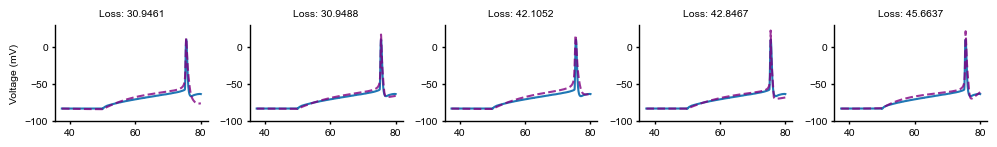

In [79]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(1,5, figsize=(10, 1.5))
    fig.subplots_adjust(wspace=0.4)

    for i in range(5):
        axs[i].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=1.5)
        axs[i].plot(time_vec, no_nn_preds[i], c='purple', alpha = 0.8, label="Single-compartment prediction", linestyle="--", linewidth=1.5)
        axs[i].set_title(f"Loss: {no_nn_losses[i]:.4f}")
        axs[i].set_ylim(-100, 30)

    axs[0].set_ylabel("Voltage (mV)")

    fig.savefig("../svg/no_nn_results.svg", bbox_inches='tight', dpi=300)

    plt.tight_layout()
    plt.show()

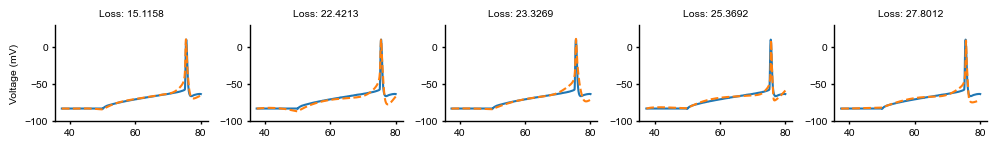

In [80]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(1,5, figsize=(10, 1.5))
    fig.subplots_adjust(wspace=0.4)

    for i in range(5):
        axs[i].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=1.5)
        axs[i].plot(time_vec, with_nn_preds[i],  alpha = 1.0, label="Single-compartment prediction", linestyle="--", linewidth=1.5)
        axs[i].set_title(f"Loss: {with_nn_losses[i]:.4f}")
        axs[i].set_ylim(-100, 30)

    axs[0].set_ylabel("Voltage (mV)")

    fig.savefig("../svg/with_nn_results.svg", bbox_inches='tight', dpi=300)

    plt.tight_layout()
    plt.show()

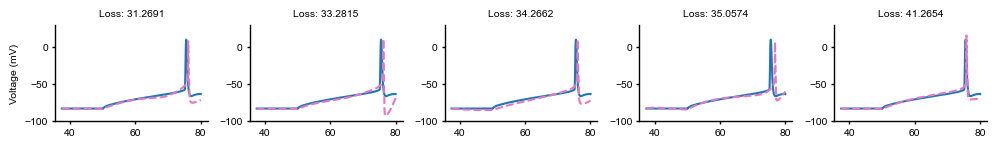

In [81]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(1,5, figsize=(10, 1.5))
    fig.subplots_adjust(wspace=0.4)

    for i in range(5):
        axs[i].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=1.5)
        axs[i].plot(time_vec, adaptive_preds[i], c = 'C6', alpha = 1.0, label="Single-compartment prediction", linestyle="--", linewidth=1.5)
        axs[i].set_title(f"Loss: {adaptive_losses[i]:.4f}")
        axs[i].set_ylim(-100, 30)

    axs[0].set_ylabel("Voltage (mV)")

    fig.savefig("../svg/adaptive_results.svg", bbox_inches='tight', dpi=300)

    plt.tight_layout()
    plt.show()

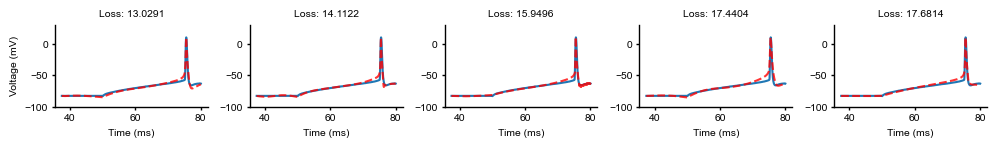

In [82]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(1,5, figsize=(10, 1.5))
    fig.subplots_adjust(wspace=0.4)

    for i in range(5):
        axs[i].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=1.5)
        axs[i].plot(time_vec, two_nns_preds[i], c = 'r',  alpha = 0.8, label="Single-compartment prediction", linestyle="--", linewidth=1.5)
        axs[i].set_title(f"Loss: {two_nns_losses[i]:.4f}")
        axs[i].set_ylim(-100, 30)
        axs[i].set_xlabel('Time (ms)')

    axs[0].set_ylabel("Voltage (mV)")

    fig.savefig("../svg/two_nns_results.svg", bbox_inches='tight', dpi=300)

    plt.tight_layout()
    plt.show()

In [86]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("20.0cm", "16.3cm",
           
    Panel(
          SVG("../svg/no_nn_results.svg").scale(svg_scale),
          Text("a", 10, 12.0, **kwargs_text),
    ).move(0, 0),
    Panel(
          SVG("../svg/with_nn_results.svg").scale(svg_scale),
          Text("b", 10, 12.0, **kwargs_text),
    ).move(0, 150),

    Panel(
          SVG("../svg/adaptive_results.svg").scale(svg_scale),
          Text("c", 10, 12.0, **kwargs_text),
    ).move(0, 300),
    Panel(
          SVG("../svg/two_nns_results.svg").scale(svg_scale),
          Text("d", 10, 12.0, **kwargs_text),
    ).move(0, 450),


)

#!mkdir -p fig
f.save("../fig/adaptive_spike_regions.svg")
svg("../fig/adaptive_spike_regions.svg")

In [4]:
root_search_preds = np.load("../results/root_search_pred.npy")
root_search_current = np.load("../results/root_search_current.npy")
root_search_is = np.load("../results/root_search_i_s.npy")
root_search_loss = np.load("../results/root_search_loss.npy")

analytic_preds = np.load("../results/analytic_pred.npy")
analytic_current = np.load("../results/analytic_current.npy")
analytic_is = np.load("../results/analytic_i_s.npy")
analytic_loss = np.load("../results/analytic_loss.npy")

trained_preds = np.load("../results/trained_pred.npy")
trained_current = np.load("../results/trained_current.npy")
trained_is = np.load("../results/trained_i_s.npy")
trained_loss = np.load("../results/trained_loss.npy")

v_data_long = np.load("../results/v_data_long.npy")
time_vec_long = np.arange(0, 250+2*0.025, 0.025)
time_vec_long = time_vec_long[1500:]


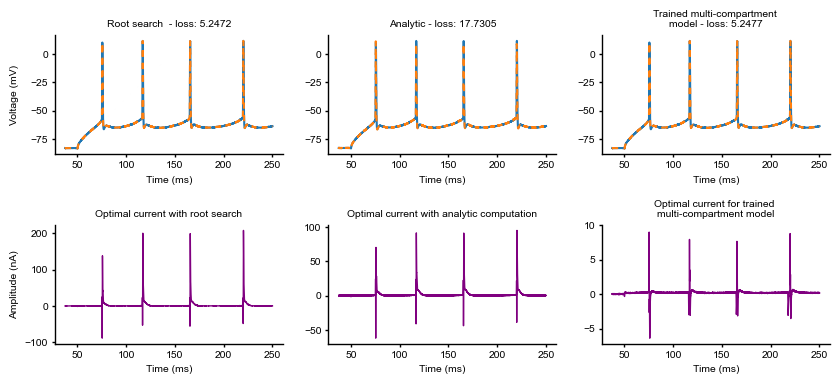

In [101]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(2,3, figsize=(10, 4))
    fig.subplots_adjust(wspace=0.2, hspace=0.6)

    axs[0,0].plot(time_vec_long, v_data_long[0], c = 'C0', label="Multi-compartment target", linewidth=1.5)
    axs[0,0].plot(time_vec_long, root_search_preds, c='C1', linestyle="--", dashes=(3, 3), label="Root search prediction", linewidth=1.5)
    axs[0,0].set_title(f"Root search  - loss: {root_search_loss:.4f}")
    axs[0,0].set_ylabel("Voltage (mV)", labelpad=8)

    axs[1,0].plot(time_vec_long, root_search_current, c='purple', linewidth=1)
    axs[1,0].set_title("Optimal current with root search")
    axs[1,0].set_ylabel("Amplitude (nA)")

    axs[0,1].plot(time_vec_long, v_data_long[0], label="Multi-compartment target", linewidth=1.5)
    axs[0,1].plot(time_vec_long, analytic_preds, c='C1', linestyle="--", dashes=(3, 3), label="Analytic prediction", linewidth=1.5)
    axs[0,1].set_title(f"Analytic - loss: {analytic_loss:.4f}")

    axs[1,1].plot(time_vec_long, analytic_current, c='purple', linewidth=1)
    axs[1,1].set_title("Optimal current with analytic computation")

    axs[0,2].plot(time_vec_long, v_data_long[0], label="Multi-compartment target", linewidth=1.5)
    axs[0,2].plot(time_vec_long, trained_preds, c='C1', linestyle="--", dashes=(3, 3), label="Trained prediction", linewidth=1.5)
    axs[0,2].set_title(f"Trained multi-compartment \nmodel - loss: {trained_loss:.4f}")

    axs[1,2].plot(time_vec_long, trained_current, c='purple', linewidth=1)
    axs[1,2].set_title("Optimal current for trained \nmulti-compartment model")
    axs[1,2].set_yticks([-5,0,5,10])

    for ax in axs.flat:
        ax.set_xlabel("Time (ms)")

    fig.savefig("../svg/optimal_current.svg", bbox_inches='tight', dpi=300)

    plt.show()

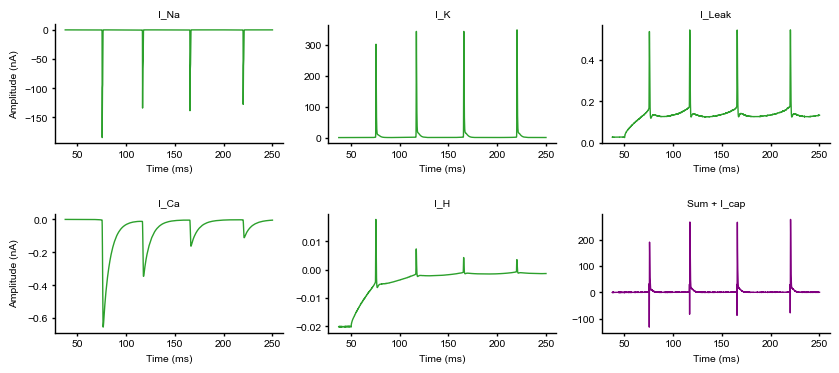

In [ ]:
import jax.numpy as jnp

area_cm2 = 2 * jnp.pi * 8.0 * 197 * 1e-8

dV = jnp.diff(root_search_preds) / 0.025  # in mV/ms
dV = jnp.append(dV, 0.0)  # pad to match length


cm = 1.0
I_cap = cm * dV * area_cm2 * 1000

with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(2,3,figsize=(10,4))
    fig.subplots_adjust(wspace=0.2, hspace=0.6)
    
    axs[0,0].plot(time_vec_long, root_search_is[:,0] * area_cm2 * 1e6, c = 'C2')
    axs[0,0].set_title('I_Na')
    axs[0,0].set_ylabel("Amplitude (nA)")
    axs[0,1].plot(time_vec_long, root_search_is[:,1] * area_cm2 * 1e6, c = 'C2')
    axs[0,1].set_title('I_K')
    axs[0,2].plot(time_vec_long, root_search_is[:,2] * area_cm2 * 1e6, c = 'C2')
    axs[0,2].set_title('I_Leak')
    axs[1,0].plot(time_vec_long, root_search_is[:,3] * area_cm2 * 1e6, c = 'C2')
    axs[1,0].set_title('I_Ca')
    axs[1,0].set_ylabel("Amplitude (nA)", labelpad=6)
    axs[1,1].plot(time_vec_long, root_search_is[:,4] * area_cm2 * 1e6, c = 'C2')
    axs[1,1].set_title('I_H')
    axs[1,2].plot(time_vec_long, (root_search_is[:,0] + root_search_is[:,1] + root_search_is[:,2] + root_search_is[:,3] + root_search_is[:,4]) * area_cm2 * 1e6 + I_cap, c = 'purple') #+ I_cap
    axs[1,2].set_title('Sum + I_cap')

    for ax in axs.flat:
        ax.set_xlabel("Time (ms)")

    fig.savefig("../svg/channel_current.svg", bbox_inches='tight', dpi=300)

    plt.show()

In [97]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("20.0cm", "18.0cm",
           
    Panel(
          SVG("../svg/optimal_current.svg").scale(svg_scale),
          Text("a", 10, 12.0, **kwargs_text),
    ).move(0, 0),
    Panel(
          SVG("../svg/channel_current.svg").scale(svg_scale),
          Text("b", 10, 12.0, **kwargs_text),
    ).move(0, 340),


)

#!mkdir -p fig
f.save("../fig/optimal_and_channel_currents.svg")
svg("../fig/optimal_and_channel_currents.svg")

In [102]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("20.0cm", "9.0cm",
           
    Panel(
          SVG("../svg/optimal_current.svg").scale(svg_scale)
    ).move(0, 0),


)

#!mkdir -p fig
f.save("../fig/optimal_currents.svg")
svg("../fig/optimal_currents.svg")

In [103]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("20.0cm", "9.0cm",
           
    Panel(
          SVG("../svg/channel_current.svg").scale(svg_scale)
    ).move(0, 0),


)

#!mkdir -p fig
f.save("../fig/channel_currents.svg")
svg("../fig/channel_currents.svg")

In [5]:
best_model_u = np.load("../results/best_model_u.npy")
best_model_nn_reses = np.load("../results/best_model_nn_reses.npy")
best_model_additional_currents = np.load("../results/best_model_additional_currents.npy")

best_model_pred_long = np.load("../results/best_model_pred_long.npy")
v_data_long = np.load("../results/best_model_data_long.npy")

time_vec_long

array([ 37.5  ,  37.525,  37.55 , ..., 249.975, 250.   , 250.025],
      shape=(8502,))

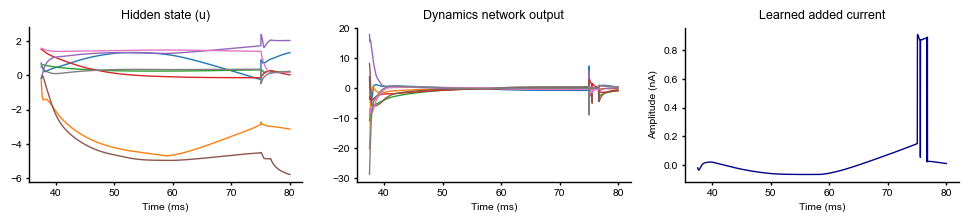

In [6]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(1,3, figsize = (12,2))
    axs[0].plot(time_vec, best_model_u)
    axs[0].set_title("Hidden state (u)", fontsize = 9)
    axs[1].plot(time_vec, best_model_nn_reses)
    axs[1].set_title("Dynamics network output", fontsize = 9)
    axs[2].plot(time_vec, best_model_additional_currents, color = "darkblue")
    axs[2].set_title("Learned added current", fontsize = 9)
    axs[2].set_ylabel("Amplitude (nA)")

    for ax in axs.flat:
        ax.set_xlabel("Time (ms)")

    fig.savefig("../svg/best_model_details.svg", bbox_inches='tight', dpi = 300)

    plt.show()

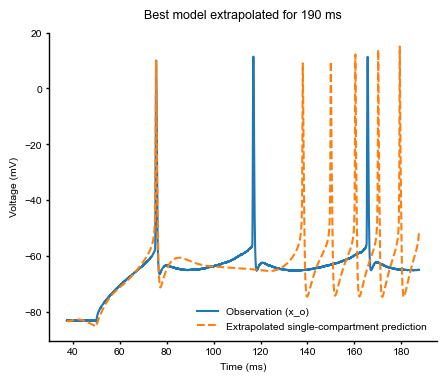

In [8]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, ax = plt.subplots(1,1, figsize = (5,4))
    ax.plot(time_vec_long[:6000], v_data_long[0][:6000], label="Observation (x_o)", linewidth=1.5)
    ax.plot(time_vec_long[:6000], best_model_pred_long[:6000], label="Extrapolated single-compartment prediction", linestyle="--", linewidth=1.5)
    ax.set_title("Best model extrapolated for 190 ms", fontsize = 9, pad = 10)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Voltage (mV)")
    ax.legend()

    fig.savefig("../svg/best_model_generalized.svg", bbox_inches='tight', dpi = 300)

    plt.show()

In [7]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("23.0cm", "14.5cm",
           
    Panel(
          SVG("../svg/best_model_details.svg").scale(svg_scale),
          Text("a", 10, 12.0, **kwargs_text),
    ).move(0, 0),
    Panel(
          SVG("../svg/best_model_generalized.svg").scale(svg_scale),
          Text("b", 10, 20.0, **kwargs_text),
    ).move(0, 200),
    Panel(
          SVG("../svg/optimized_parameters_two_nns.svg").scale(svg_scale),
          Text("c", 10, 20.0, **kwargs_text),
    ).move(415, 200),

)

#!mkdir -p fig
f.save("../fig/best_model.svg")
svg("../fig/best_model.svg")

In [4]:
longer_best_preds = np.load("../results/longer_ten_best_preds.npy")
longer_best_losses = np.load("../results/longer_ten_best_losses.npy")
longer_best_preds_reg = np.load("../results/longer_ten_best_preds_reg.npy")
longer_best_losses_reg = np.load("../results/longer_ten_best_losses_reg.npy")
v_data_longer = np.load("../results/v_data_longer.npy")

time_vec = np.arange(0, 150+2*0.025, 0.025)
time_vec = time_vec[1500:]

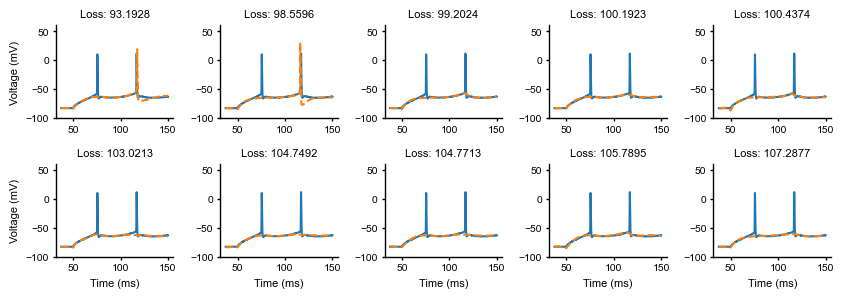

In [19]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(2,5, figsize = (10,3))
    fig.subplots_adjust(wspace=0.4)
    fig.subplots_adjust(hspace=0.5)
    
    for i in range(2):
        for j in range(5):
            axs[i,j].plot(time_vec, v_data_longer[0], label="Multi-compartment target", linewidth=1.5)
            axs[i,j].plot(time_vec, longer_best_preds[i*5+j], label="Single-compartment prediction", linestyle="--", linewidth=1.5)
            axs[i,j].set_title(f"Loss: {longer_best_losses[i*5+j]:.4f}", fontsize = 8)
            axs[i,j].set_ylim(-100, 60)

    for j in range(5):
        axs[1,j].set_xlabel("Time (ms)", fontsize=8)
    for i in range(2):
        axs[i,0].set_ylabel("Voltage (mV)", fontsize=8)

    fig.savefig("../svg/best_preds_longer.svg", bbox_inches='tight', dpi = 300)

    plt.show()

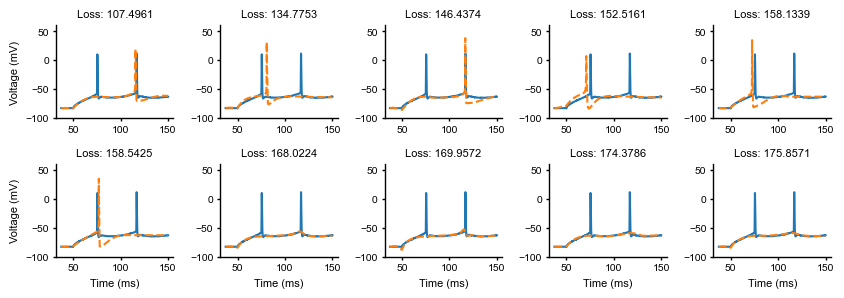

In [20]:
with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(2,5, figsize = (10,3))
    fig.subplots_adjust(wspace=0.4)
    fig.subplots_adjust(hspace=0.5)
    
    for i in range(2):
        for j in range(5):
            axs[i,j].plot(time_vec, v_data_longer[0], label="Multi-compartment target", linewidth=1.5)
            axs[i,j].plot(time_vec, longer_best_preds_reg[i*5+j], label="Single-compartment prediction", linestyle="--", linewidth=1.5)
            axs[i,j].set_title(f"Loss: {longer_best_losses_reg[i*5+j]:.4f}", fontsize = 8)
            axs[i,j].set_ylim(-100, 60)

    for j in range(5):
        axs[1,j].set_xlabel("Time (ms)", fontsize=8)
    for i in range(2):
        axs[i,0].set_ylabel("Voltage (mV)", fontsize=8)

    fig.savefig("../svg/best_preds_longer_reg.svg", bbox_inches='tight', dpi = 300)

    plt.show()

In [40]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("20.1cm", "14.6cm",
           
    Panel(
          SVG("../svg/best_preds_longer.svg").scale(svg_scale),
          Text("a", 10, 12.0, **kwargs_text),
    ).move(0, 0),
    Line([(0, 272), (1000, 272)], width=1.5, color="black"),

    Panel(
          SVG("../svg/best_preds_longer_reg.svg").scale(svg_scale),
          Text("b", 10, 12.0, **kwargs_text),
    ).move(0, 280),

)

#!mkdir -p fig
f.save("../fig/best_results_longer.svg")
svg("../fig/best_results_longer.svg")

In [46]:
summed_errors = np.load("../results/single_summed_errors.npy")
scaled_dtw_errors = np.load("../results/single_dtw_errors.npy")
x_pred_single = np.load("../results/single_preds.npy")

multi_summed_errors = np.load("../results/multi_summed_errors.npy")
multi_scaled_dtw_errors = np.load("../results/multi_dtw_errors.npy")
x_pred_multi = np.load("../results/multi_preds.npy")

v_data_long = np.load("../results/v_data_long.npy")


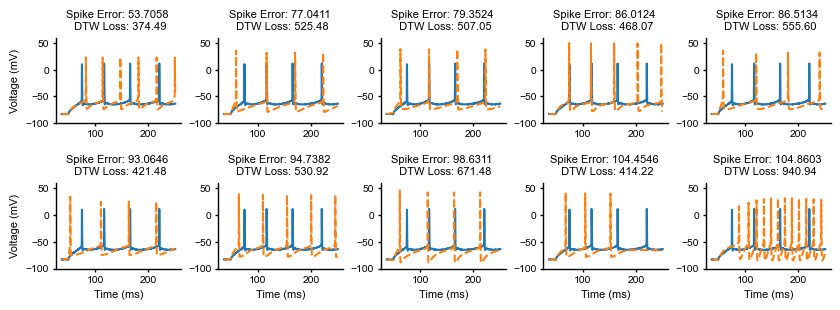

In [75]:
inds = np.argsort(summed_errors)

with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(2,5, figsize = (10,3))
    fig.subplots_adjust(hspace=0.7, wspace=0.3)
    for i in range(2):
        for j in range(5):
            axs[i,j].plot(time_vec_long, v_data_long[0], label="Multi-compartment target", linewidth=1.5)
            axs[i,j].plot(time_vec_long, x_pred_single[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=1.5)
            axs[i,j].set_title(f"Spike Error: {summed_errors[inds[i*5+j]]:.4f} \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 8)
            axs[i,j].set_ylim(-100, 60)

    for j in range(5):
        axs[1,j].set_xlabel("Time (ms)", fontsize=8)
    for i in range(2):
        axs[i,0].set_ylabel("Voltage (mV)", fontsize=8)

    fig.savefig("../svg/single_summed_errors.svg", bbox_inches='tight', dpi = 300)

    plt.show()

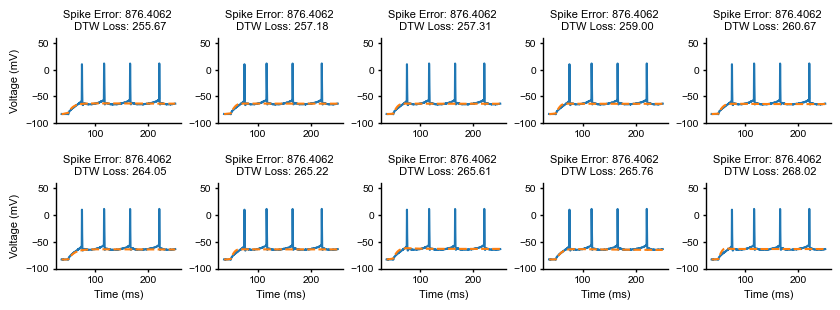

In [76]:
inds = np.argsort(scaled_dtw_errors)

with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(2,5, figsize = (10,3))
    fig.subplots_adjust(hspace=0.7, wspace=0.3)
    for i in range(2):
        for j in range(5):
            axs[i,j].plot(time_vec_long, v_data_long[0], label="Multi-compartment target", linewidth=1.5)
            axs[i,j].plot(time_vec_long, x_pred_single[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=1.5)
            axs[i,j].set_title(f"Spike Error: {summed_errors[inds[i*5+j]]:.4f} \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 8)
            axs[i,j].set_ylim(-100, 60)

    for j in range(5):
        axs[1,j].set_xlabel("Time (ms)", fontsize=8)
    for i in range(2):
        axs[i,0].set_ylabel("Voltage (mV)", fontsize=8)

    fig.savefig("../svg/single_dtw_errors.svg", bbox_inches='tight', dpi = 300)

    plt.show()

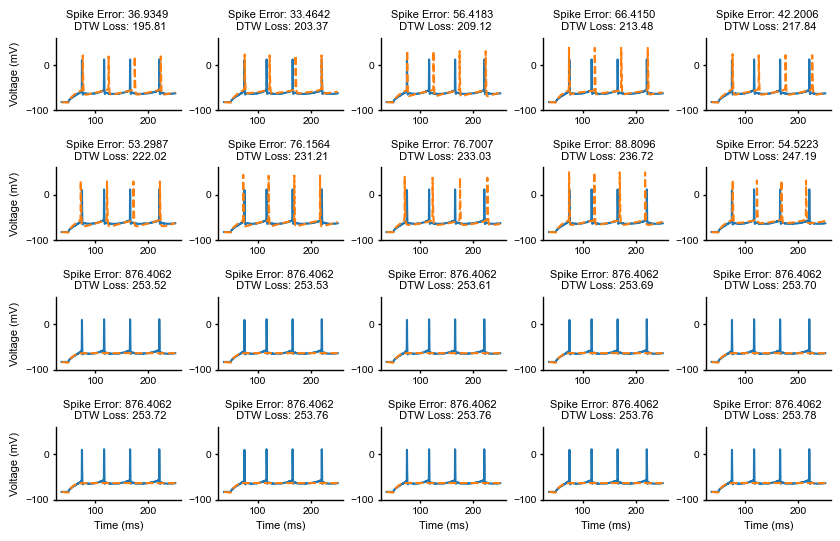

In [77]:
inds = np.argsort(multi_scaled_dtw_errors)

with mpl.rc_context(fname="../../../.matplotlibrc"):
    fig, axs = plt.subplots(4,5, figsize = (10,6))
    fig.subplots_adjust(hspace=0.8, wspace=0.3)
    for i in range(4):
        for j in range(5):
            axs[i,j].plot(time_vec_long, v_data_long[0], label="Multi-compartment target", linewidth=1.5)
            axs[i,j].plot(time_vec_long,x_pred_multi[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=1.5)
            axs[i,j].set_title(f"Spike Error: {multi_summed_errors[inds[i*5+j]]:.4f} \n DTW Loss: {multi_scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 8)
            axs[i,j].set_ylim(-100, 60)

    for j in range(5):
        axs[3,j].set_xlabel("Time (ms)", fontsize=8)
    for i in range(4):
        axs[i,0].set_ylabel("Voltage (mV)", fontsize=8)

    fig.savefig("../svg/multi_dtw_errors.svg", bbox_inches='tight', dpi = 300)

    plt.show()

In [11]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("20.1cm", "15.1cm",
           
    Panel(
          SVG("../svg/single_dtw_errors.svg").scale(svg_scale),
          Text("a", 10, 12.0, **kwargs_text),
    ).move(0, 0),
    Line([(0, 285), (1000, 285)], width=1.5, color="black"),

    Panel(
          SVG("../svg/single_summed_errors.svg").scale(svg_scale),
          Text("b", 10, 12.0, **kwargs_text),
    ).move(0, 295),

)

#!mkdir -p fig
f.save("../fig/single_errors.svg")
svg("../fig/single_errors.svg")

In [79]:
import time
import IPython.display as IPd
from svgutils.compose import *

def svg(img):
    IPd.display(IPd.HTML('<img src="{}" / >'.format(img, time.time())))

# > Inkscape pixel is 1/90 of an inch, other software usually uses 1/72.
# > http://www.inkscapeforum.com/viewtopic.php?f=6&t=5964
svg_scale = 1.25  # set this to 1.25 for Inkscape, 1.0 otherwise

# Panel letters in Helvetica Neue, 12pt, Medium
kwargs_text = {'size': '12pt', 'font': 'Arial', 'weight': '800'}

f = Figure("20.1cm", "13.0cm",
    Panel(
          SVG("../svg/multi_dtw_errors.svg").scale(svg_scale)
    ).move(0, 0),

)

#!mkdir -p fig
f.save("../fig/multi_errors.svg")
svg("../fig/multi_errors.svg")